# 04 · ResNet50
**Owner:** Pihu Pandey (230953134)

ResNet50 (He et al., 2016): 50 layers built from bottleneck residual blocks with identity shortcut connections and batch normalisation, which let a much deeper network train well and learn more abstract features.

**Interim set-up (unoptimised):** ImageNet weights, backbone frozen, global average pooling,
then the common head Dense(256, ReLU) → Dropout(0.5) → Dense(2, softmax).
Because the backbone is frozen, its pooled features are computed once and cached
(`src/features.py`); only the head is trained. The last cell rebuilds the full end-to-end
model and checks it gives the same predictions as the cached path.

In [1]:
import os, sys
os.environ.setdefault("KERAS_BACKEND", "torch")   # Keras 3 backend used for our runs (CPU); "tensorflow" also works
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))        # make the project's src/ package importable

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from src import config, data_pipeline as dp, models, features, training

keras.utils.set_random_seed(config.SEED)
print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.15.1 | backend: torch


## Pooled features from the frozen backbone (cached)

In [2]:
X_train, y_train, _ = features.extract_features("resnet50", "train")
X_val, y_val, _ = features.extract_features("resnet50", "val")
manifest = pd.read_csv(config.SPLIT_MANIFEST)
class_weight = dp.class_weights(manifest)
print("train", X_train.shape, "val", X_val.shape, "| class weights", class_weight)

loaded cached resnet50_train.npz: (4343, 2048) (extracted earlier in 9.0 min)


loaded cached resnet50_val.npz: (1086, 2048) (extracted earlier in 1.9 min)
train (4343, 2048) val (1086, 2048) | class weights {0: 2.1185365853658538, 1: 0.654460518384569}


## Model

In [3]:
head = models.build_head(models.head_input_dim(["resnet50"]), name="resnet50_head")
full_model = models.assemble_cnn(["resnet50"], head)
full_model.summary()

Model: "resnet50_full"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_224x224 (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_base (Functional)      │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_head (Functional)      │ (None, 2)              │       525,058 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Train the classifier head

In [4]:
history = training.train(head, X_train, y_train, X_val, y_val,
                         learning_rate=config.HEAD_LR, class_weight=class_weight)

Epoch 1/30


136/136 - 1s - 9ms/step - accuracy: 0.9443 - loss: 0.1537 - val_accuracy: 0.9779 - val_loss: 0.0760


Epoch 2/30


136/136 - 1s - 8ms/step - accuracy: 0.9767 - loss: 0.0745 - val_accuracy: 0.9761 - val_loss: 0.1074


Epoch 3/30


...

136/136 - 1s - 10ms/step - accuracy: 0.9903 - loss: 0.0243 - val_accuracy: 0.9871 - val_loss: 0.0526


Epoch 9/30


136/136 - 1s - 10ms/step - accuracy: 0.9848 - loss: 0.0449 - val_accuracy: 0.9890 - val_loss: 0.0556


Epoch 10/30


136/136 - 1s - 10ms/step - accuracy: 0.9896 - loss: 0.0322 - val_accuracy: 0.9862 - val_loss: 0.0491


## Validation results

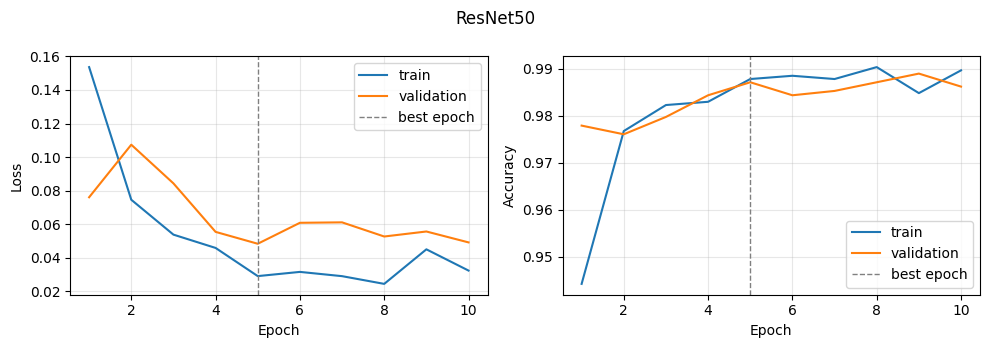

    accuracy: 0.9871
   precision: 0.9880
      recall: 0.9952
 specificity: 0.9609
          f1: 0.9916
    macro_f1: 0.9820
     roc_auc: 0.9986
   confusion: [[TN, FP], [FN, TP]] = [[246, 10], [4, 826]]


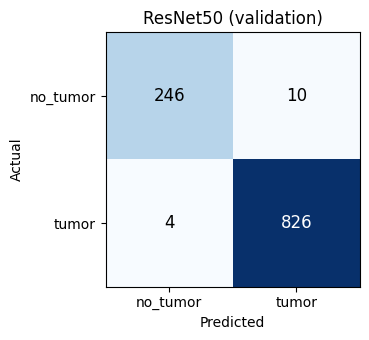

epochs run: 10 | best epoch: 5 | head training time: 12.6 s


In [5]:
training.plot_history(history, "ResNet50", config.FIG_DIR / "resnet50_curves.png")
metrics, prob, pred = training.evaluate(head, X_val, y_val)
training.print_metrics(metrics)
training.plot_confusion(metrics["confusion_matrix"], "ResNet50 (validation)",
                        config.FIG_DIR / "resnet50_confusion.png")
record = training.save_results("resnet50", metrics, history, head,
                               extra={"total_params_full_model": int(full_model.count_params()),
                                       "learning_rate": config.HEAD_LR})
print("epochs run:", record["epochs_run"], "| best epoch:", record["best_epoch"],
      "| head training time:", record["train_seconds"], "s")

## Sanity check: full model = cached-feature path

In [6]:
xb, _ = dp.make_cnn_generator("val", models.BACKBONES["resnet50"][1])[0]   # first 32 validation images
diff = np.abs(full_model.predict(xb[:16], verbose=0) - head.predict(X_val[:16], verbose=0)).max()
print(f"max |difference| in predicted probabilities: {diff:.2e}")

Found 1086 images belonging to 2 classes.


max |difference| in predicted probabilities: 0.00e+00
